<a href="https://colab.research.google.com/github/sofiascarvalho/Projeto_Integrador_AWS/blob/main/Analise_Sentimento_AWS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **0. Instalação de Pacotes**

Esta seção contém todas as instalações de bibliotecas necessárias para o notebook. Execute esta célula para garantir que todos os pacotes estejam disponíveis.

In [ ]:
# Instalações de bibliotecas
!pip install vaderSentiment
!pip install leia-br
!pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 4.2 MB/s eta 0:00:00


## **0.1 Importação de Bibliotecas Essenciais e Inicializações Globais**

Nesta seção, importamos todas as bibliotecas Python que serão utilizadas e inicializamos objetos globais como os analisadores de sentimento para VADER, LeIA e Transformers.

In [ ]:
# Importação das bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import pandas as pd
import unicodedata
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from LeIA import SentimentIntensityAnalyzer as SentimentIntensityAnalyzer_leia
from transformers import pipeline
from tqdm.auto import tqdm

# Inicialização dos analisadores de sentimento
sid = SentimentIntensityAnalyzer()
sid_leia = SentimentIntensityAnalyzer_leia()
# Atenção: ao usar o pipeline de transformers, se você ver um aviso sobre 'HF_TOKEN',
# considere adicionar seu token da Hugging Face aos segredos do Colab para evitar limitações de taxa.
analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## **0.2 Funções Auxiliares**

Esta seção agrupa todas as funções auxiliares definidas no notebook, como funções de análise de DataFrame, manipulação de texto, classificação de sentimento e algoritmos de ordenação (Selection Sort).

In [ ]:
def analise_df(nome, df):
  print(f"\n{'='*50}")
  print(f"\nTABELA: {nome}")
  print(f"\n{'='*50}")

  print("\nHEAD")
  display(df.head())

  print("\nTAIL")
  display(df.tail())

  print("\nINFO")
  df.info()

  print("\nDESCRIBE")
  display(df.describe())

  print("\nItens Nulos")
  print(df.isnull())

def combine_review_text(row):
    title = row['review_comment_title']
    message = row['review_comment_message']

    # Convert to string and handle NaN as empty string
    title_str = str(title) if pd.notna(title) else ''
    message_str = str(message) if pd.notna(message) else ''

    if title_str and message_str:
        return f"{title_str} - {message_str}"
    elif title_str:
        return title_str
    elif message_str:
        return message_str
    else:
        return ''

def strip_accents(text):
   """Remove accents from a string."""
   # Ensure text is a string before processing
   if isinstance(text, str):
       text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
   return text


def classificacao (pontuacao):
    """Classifies a sentiment score into textual categories."""
    if pontuacao < -0.6:
        return "muito negativo"
    elif pontuacao >= -0.6 and pontuacao < -0.2:
        return "negativo"
    elif pontuacao >= -0.2 and pontuacao < 0.2:
        return "neutro"
    elif pontuacao >= 0.2 and pontuacao < 0.6:
        return "positivo"
    else:
        return "muito positivo"

def classificacao_score (pontuacao):
    """Maps a sentiment score to a 1-5 star rating."""
    if pontuacao < -0.6:
        return 1
    elif pontuacao >= -0.6 and pontuacao < -0.2:
        return 2
    elif pontuacao >= -0.2 and pontuacao < 0.2:
        return 3
    elif pontuacao >= 0.2 and pontuacao < 0.6:
        return 4
    else:
        return 5

def calcular_sentimento_vader(texto):
    # O texto combinado já lida com NaN e strings vazias, mas a validação interna é boa.
    if not isinstance(texto, str) or texto.strip() == '':
        return 0.0
    return sid.polarity_scores(texto)['compound']

def sentimento_score_por_review_score(score):
    """Calcula uma pontuação numérica de sentimento (-1 a 1) a partir do review_score (1 a 5)."""
    # Mapeamento do review_score para uma escala de -1 a 1
    if score >= 4:
        return round((score - 3) / 2, 2) # Ex: 4 -> 0.5, 5 -> 1.0
    elif score == 3:
        return 0.0 # Neutro
    else:
        return round((score - 3) / 2, 2) # Ex: 2 -> -0.5, 1 -> -1.0

def calcular_sentimento_leia(row):
    texto = str(row['review_text_combined']).strip() # Usar review_text_combined

    if not texto:
        # Se não houver texto, use o review_score para inferir o sentimento
        return sentimento_score_por_review_score(int(row['review_score']))

    # Se houver texto, use o LeIA normalmente
    scores = sid_leia.polarity_scores(texto)
    return scores['compound']

def map_transformer_label_to_score(label_str):
    """Maps transformer string labels (e.g., '3 stars') to a numerical sentiment score (-1 to 1)."""
    if '1 star' in label_str:
        return -1.0
    elif '2 stars' in label_str:
        return -0.5
    elif '3 stars' in label_str:
        return 0.0
    elif '4 stars' in label_str:
        return 0.5
    elif '5 stars' in label_str:
        return 1.0
    return 0.0 # Default or error case, assuming neutral

def selection_sort_by_length(data):
    n = len(data)
    # Criamos uma cópia da lista original para não modificar o DataFrame diretamente
    # e para trabalhar com os textos reais para ordenação.
    sorted_data = list(data)

    for i in range(n):
        # Encontra o índice do maior elemento restante
        max_idx = i
        for j in range(i + 1, n):
            if len(sorted_data[j]) > len(sorted_data[max_idx]): # Alterado para > para ordenar do maior para o menor
                max_idx = j

        # Troca o elemento encontrado com o primeiro elemento não classificado
        sorted_data[i], sorted_data[max_idx] = sorted_data[max_idx], sorted_data[i]
    return sorted_data

def selection_sort_by_value_descending(data_with_values):
    """Sorts a list of (value, text) tuples in descending order by value using Selection Sort."""
    n = len(data_with_values)
    sorted_data = list(data_with_values)

    for i in range(n):
        # Encontra o índice do maior valor restante
        max_idx = i
        for j in range(i + 1, n):
            if sorted_data[j][0] > sorted_data[max_idx][0]: # Compara os valores (primeiro elemento da tupla)
                max_idx = j

        # Troca o elemento encontrado com o primeiro elemento não classificado
        sorted_data[i], sorted_data[max_idx] = sorted_data[max_idx], sorted_data[i]
    return sorted_data

#**ANALISE DESCRITIVA** - Banco de Dados de avaliações *AWS*

## **2. Análise Descritiva**

# **1. Carregamento e Entendimento dos Dados**
Nessa etapa realizaremos o carregamento organizado de todas as tabelas do projeto no Python (Google Colab ou VS Code), além de compreender o que cada tabela representa, como se relacionam e qual o papel de cada uma no fluxo de um e-commerce. Também construiremos um dicionário de dados simples, descrevendo cada variável, seu tipo, significado e função no conjunto de informações.

### **Montagem do Google Drive**
Esta célula executa o comando para montar o Google Drive no ambiente do Colab, permitindo o acesso aos arquivos armazenados na nuvem, que contêm os datasets do projeto.

## **1.2 Carregamento dos dados**
Nessa etapa carregaremos todas as tabelas do projeto no Python utilizando a biblioteca Pandas. Utilize
caminhos corretos e específicos de suas pastas. Carregue as nove tabelas: pedidos, itens do pedido,
clientes, produtos, pagamentos, avaliações, vendedores, geolocalização e auxiliar.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Carregamento dos Datasets Iniciais**
Nesta célula, todas as tabelas CSV são lidas e carregadas em DataFrames do Pandas. Cada DataFrame recebe um nome (`df_avaliacoes`, `df_clientes`, etc.) para facilitar a referência e manipulação posterior no código.

In [ ]:
#avaliações
df_avaliacoes = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/avaliacoes.csv')

#clientes
df_clientes = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/clientes.csv')

#geolocalizacao
df_geolocalizacao = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/geolocalizacao.csv')

#itens_pedidos
df_itens_pedidos = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/itens_pedidos.csv')

#pagamentos
df_pagamentos = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/pagamentos.csv')

#pedidos
df_pedidos = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/pedidos.csv')

#produtos
df_produtos = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/produtos.csv')

#tabela_auxiliar
df_tabela_auxiliar = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/tabela_auxiliar.csv')

#vendedores
df_vendedores = pd.read_csv('/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/vendedores.csv')

### **Criação do Dicionário de DataFrames**
Esta célula organiza todos os DataFrames carregados em um dicionário chamado `tabelas`. Isso permite uma iteração e manipulação mais eficiente de todos os conjuntos de dados de forma programática.

In [ ]:
tabelas = {
    'avaliacoes': df_avaliacoes,
    'clientes': df_clientes,
    'geolocalizacao': df_geolocalizacao,
    'itens_pedidos': df_itens_pedidos,
    'pagamentos': df_pagamentos,
    'pedidos': df_pedidos,
    'produtos': df_produtos,
    'tabela_auxiliar': df_tabela_auxiliar,
    'vendedores': df_vendedores
}

### **Execução da Análise Exploratória para Todas as Tabelas**
Esta célula itera sobre o dicionário `tabelas` e aplica a função `analise_df` a cada DataFrame. Isso gera uma saída detalhada para cada uma das nove tabelas, fornecendo uma visão abrangente de sua estrutura, conteúdo e integridade.

In [ ]:
for nome, df in tabelas.items():
    analise_df(nome, df)



TABELA: avaliacoes


HEAD


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



TAIL


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,NaN,"meu produto chegou e ja tenho que devolver, po...",2017-07-03 00:00:00,2017-07-03 21:01:49



INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

DESCRIBE


...


TAIL


,seller_id,seller_zip_code_prefix,seller_city,seller_state
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS
3094,9e25199f6ef7e7c347120ff175652c3b,12051,taubate,SP



INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

DESCRIBE


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000



Itens Nulos
      seller_id  seller_zip_code_prefix  seller_city  seller_state
0         False                   False        False         False
1         False                   False        False         False
2         False                   False        False         False
3         False                   False        False         False
4         False                   False        False         False
...         ...                     ...          ...           ...
3090      False                   False        False         False
3091      False                   False        False         False
3092      False                   False        False         False
3093      False                   False        False         False
3094      False                   False        False         False

[3095 rows x 4 columns]


In [ ]:
df_final = df_clientes.merge(
    df_pedidos, on='customer_id',
).merge(
    df_itens_pedidos, on='order_id',
).merge(
    df_produtos, on='product_id',
).merge(
    df_avaliacoes, on='order_id',
).merge(
    df_pagamentos, on='order_id',
).merge(
    df_vendedores, on='seller_id',
)

### **Visão Geral do DataFrame Final**
Esta célula exibe as dimensões (linhas e colunas) e as primeiras linhas do DataFrame `df_final`, que foi criado pela junção de várias tabelas. Isso nos permite ter uma rápida noção da estrutura dos dados mesclados.

In [ ]:
print(df_final.shape)
df_final.head()

(117329, 39)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40,1,credit_card,2,146.87,8577,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29,1,credit_card,8,335.48,88303,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59,1,credit_card,7,157.73,8577,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47,1,credit_card,1,173.30,8577,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52,1,credit_card,8,252.25,14940,ibitinga,SP


### **Resumo Básico das Tabelas**
Esta célula calcula e exibe um resumo básico para cada DataFrame original, incluindo o número de linhas, colunas, o total de valores nulos e o número de linhas duplicadas. É uma visão rápida da integridade estrutural de cada tabela.

In [ ]:
resumo = []
for nome, df in tabelas.items():
    resumo.append({
        "Tabela":      nome,
        "Linhas":      df.shape[0],
        "Colunas":     df.shape[1],
        "Nulos Total": df.isnull().sum().sum(),
        "Duplicatas":  df.duplicated().sum(),
    })

df_resumo = pd.DataFrame(resumo)
display(df_resumo)

,Tabela,Linhas,Colunas,Nulos Total,Duplicatas
0,avaliacoes,99224,7,145903,0
1,clientes,99441,5,0,0
2,geolocalizacao,1000163,5,0,261831
3,itens_pedidos,112650,7,0,0
4,pagamentos,103886,5,0,0
5,pedidos,99441,8,4908,0
6,produtos,32951,9,2448,0
7,tabela_auxiliar,71,2,0,0
8,vendedores,3095,4,0,0


### **Resumo Detalhado das Tabelas (incluindo Duplicatas por ID)**
Esta célula aprimora o resumo das tabelas adicionando a porcentagem de nulos e, crucialmente, identificando duplicatas com base nas colunas que provavelmente são IDs. Isso ajuda a detectar problemas de integridade de dados mais específicos em chaves primárias.

In [ ]:


resumo = []

for nome, df in tabelas.items():
    # 1. Identifica colunas que provavelmente são IDs (contêm 'id' ou 'customer', 'order', etc)
    # Isso ajuda a achar duplicatas "escondidas" por IDs únicos
    cols_id = [c for c in df.columns if 'id' in c.lower() or 'pk' in c.lower()]

    # 2. Calcula duplicatas na chave principal (se existir)
    # Se houver mais de um ID, pegamos o primeiro (geralmente o ID da própria tabela)
    dup_chave = 0
    if cols_id:
        dup_chave = df.duplicated(subset=[cols_id[0]]).sum()

    resumo.append({
        "Tabela":       nome,
        "Linhas":       df.shape[0],
        "Colunas":      df.shape[1],
        "Nulos Total":  df.isnull().sum().sum(),
        "Nulos %":      f"{(df.isnull().sum().sum() / (df.size) * 100):.1f}%",
        "Dup. Linha":   df.duplicated().sum(),
        "Dup. ID":      dup_chave, # <--- O "pulo do gato" está aqui
        "Chave Usada":  cols_id[0] if cols_id else "N/A"
    })

df_resumo = pd.DataFrame(resumo)
display(df_resumo)


,Tabela,Linhas,Colunas,Nulos Total,Nulos %,Dup. Linha,Dup. ID,Chave Usada
0,avaliacoes,99224,7,145903,21.0%,0,814,review_id
1,clientes,99441,5,0,0.0%,0,0,customer_id
2,geolocalizacao,1000163,5,0,0.0%,261831,0,N/A
3,itens_pedidos,112650,7,0,0.0%,0,13984,order_id
4,pagamentos,103886,5,0,0.0%,0,4446,order_id
5,pedidos,99441,8,4908,0.6%,0,0,order_id
6,produtos,32951,9,2448,0.8%,0,0,product_id
7,tabela_auxiliar,71,2,0,0.0%,0,0,N/A
8,vendedores,3095,4,0,0.0%,0,0,seller_id


### **Conversão de Colunas de Data em `df_avaliacoes`**
Esta célula converte as colunas `review_creation_date` e `review_answer_timestamp` do DataFrame `df_avaliacoes` para o tipo de dado `datetime`. Isso é essencial para análises temporais, como duração entre eventos e tendências ao longo do tempo.

In [ ]:
df_avaliacoes['review_creation_date']    = pd.to_datetime(df_avaliacoes['review_creation_date'])
df_avaliacoes['review_answer_timestamp'] = pd.to_datetime(df_avaliacoes['review_answer_timestamp'])

print('Info of df_avaliacoes after datetime conversion:')
df_avaliacoes.info()
print('\nHead of df_avaliacoes after datetime conversion:')
display(df_avaliacoes.head())

Info of df_avaliacoes after datetime conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB

Head of df_avaliacoes after datetime conversion:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


### **Tratamento e Combinação de Texto em Avaliações**
Esta célula agora realiza o seguinte:

1.  **Combinação de Título e Mensagem:** Cria uma nova coluna `review_text_combined` que concatena `review_comment_title` e `review_comment_message`. Se apenas um estiver presente, ele é usado. Se ambos forem nulos, a coluna combinada fica vazia.
2.  **Filtragem de Avaliações Sem Texto:** Remove as linhas do DataFrame `df_avaliacoes` onde a nova coluna `review_text_combined` está vazia, ou seja, avaliações que não possuíam título nem mensagem original.
3.  **Resumo da Contagem:** Exibe a quantidade total de avaliações originais, a quantidade de avaliações que restaram após a filtragem (com algum texto combinado) e a quantidade de avaliações que foram removidas por não terem conteúdo textual.

In [ ]:
# A conversão para datetime já foi feita na célula XBjzPiiIjXFc. Removendo duplicação.
# df_avaliacoes['review_creation_date']    = pd.to_datetime(df_avaliacoes['review_creation_date'])
# df_avaliacoes['review_answer_timestamp'] = pd.to_datetime(df_avaliacoes['review_answer_timestamp'])

original_total_reviews = len(df_avaliacoes)



df_avaliacoes['review_text_combined'] = df_avaliacoes.apply(combine_review_text, axis=1)

# Filter df_avaliacoes to remove rows where 'review_text_combined' is empty
df_avaliacoes = df_avaliacoes[df_avaliacoes['review_text_combined'] != ''].copy()

# df_avaliacoes_com_texto now includes all rows that have any combined text
df_avaliacoes_com_texto = df_avaliacoes.copy()

print(f"Total de avaliações originais: {original_total_reviews:,}")
print(f"Avaliações com texto combinado (título ou mensagem): {len(df_avaliacoes):,}")
print(f"Avaliações removidas (sem título e sem comentário original): {original_total_reviews - len(df_avaliacoes):,}")

Total de avaliações originais: 99,224
Avaliações com texto combinado (título ou mensagem): 42,706
Avaliações removidas (sem título e sem comentário original): 56,518


### **Padronização de Texto em Avaliações (Minúsculas e Remoção de Acentos)**
Esta célula padroniza o texto na coluna `review_text_combined` convertendo todo o conteúdo para minúsculas e removendo caracteres acentuados. Isso é crucial para análises de texto, garantindo que palavras como 'Ótimo' e 'otimo' sejam tratadas como a mesma entidade.

In [ ]:
# Convert to lowercase and remove accents from the combined text column
# The 'review_text_combined' column should already contain only strings or empty strings from the previous step
df_avaliacoes['review_text_combined'] = df_avaliacoes['review_text_combined'].str.lower().apply(strip_accents)

print("Coluna 'review_text_combined' padronizada (minúsculas e sem acentos).")
print('\nExemplo de df_avaliacoes.head() após padronização:')
display(df_avaliacoes[['review_text_combined', 'review_comment_title', 'review_comment_message']].head())

Coluna 'review_text_combined' padronizada (minúsculas e sem acentos).

Exemplo de df_avaliacoes.head() após padronização:


,review_text_combined,review_comment_title,review_comment_message
3,recebi bem antes do prazo estipulado.,NaN,Recebi bem antes do prazo estipulado.
4,parabens lojas lannister adorei comprar pela i...,NaN,Parabéns lojas lannister adorei comprar pela I...
9,recomendo - aparelho eficiente. no site a marc...,recomendo,aparelho eficiente. no site a marca do aparelh...
12,"mas um pouco ,travando...pelo valor ta boa.\r\n",NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,"super recomendo - vendedor confiavel, produto ...",Super recomendo,"Vendedor confiável, produto ok e entrega antes..."


### **Conversão e Análise de Colunas de Data em `df_pedidos`**
Esta célula converte múltiplas colunas de data do DataFrame `df_pedidos` para o tipo `datetime`. Em seguida, ela verifica a contagem de pedidos com datas de entrega nulas (`order_delivered_customer_date`) agrupadas pelo status do pedido, confirmando que esses nulos estão associados a pedidos ainda não entregues ou cancelados, e não a erros de dados.

In [ ]:
colunas_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in colunas_data:
    df_pedidos[col] = pd.to_datetime(df_pedidos[col])

# Confirma que nulos são pedidos não entregues (não é erro)
print("Nulos em 'data de entrega' por status:")
print(df_pedidos[df_pedidos['order_delivered_customer_date'].isnull()]['order_status'].value_counts())
print(f"\nTotal de pedidos mantidos: {len(df_pedidos):,}")

Nulos em 'data de entrega' por status:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Total de pedidos mantidos: 99,441


### **Tratamento de Categorias Nulas em `df_produtos`**
Esta célula preenche os valores nulos na coluna `product_category_name` do DataFrame `df_produtos` com a string 'sem_categoria'. Isso garante que todos os produtos tenham uma categoria, evitando problemas em análises ou visualizações que dependem dessa informação.

In [ ]:
nulos_categoria = df_produtos['product_category_name'].isnull().sum()

df_produtos['product_category_name'] = df_produtos['product_category_name'].fillna('sem_categoria')

print(f"Categorias preenchidas com 'sem_categoria': {nulos_categoria}")
print(f"Total de produtos: {len(df_produtos):,}")

Categorias preenchidas com 'sem_categoria': 610
Total de produtos: 32,951


### **Verificação Final de Nulos e Duplicatas em Tabelas Selecionadas**
Esta célula executa uma verificação rápida de valores nulos e linhas duplicadas nas tabelas `itens_pedidos`, `pagamentos`, `clientes`, `vendedores` e `tabela_auxiliar`. O objetivo é confirmar se, após os tratamentos anteriores e a análise inicial, essas tabelas estão limpas e prontas para uso.

In [ ]:
for nome, df in {
    "itens_pedidos":   df_itens_pedidos,
    "pagamentos":      df_pagamentos,
    "clientes":        df_clientes,
    "vendedores":      df_vendedores,
    "tabela_auxiliar": df_tabela_auxiliar
}.items():
    nulos = df.isnull().sum().sum()
    dups  = df.duplicated().sum()
    print(f"{nome:20s} → nulos: {nulos} | duplicatas: {dups}")

itens_pedidos        → nulos: 0 | duplicatas: 0
pagamentos           → nulos: 0 | duplicatas: 0
clientes             → nulos: 0 | duplicatas: 0
vendedores           → nulos: 0 | duplicatas: 0
tabela_auxiliar      → nulos: 0 | duplicatas: 0


## **3. Análise de Sentimento**

Nesta seção, exploraremos os resultados da análise de sentimento utilizando três modelos distintos: VADER, LeIA e Transformers. Avaliaremos suas pontuações, classificações e como se comparam com as avaliações originais dos clientes.

### **Visualização dos Resultados da Análise de Sentimento (VADER)**
Esta célula exibe as colunas `review_text_combined`, `review_score` e a recém-criada `pontuacao_sentimento_vader` do DataFrame `df_avaliacoes`. Isso permite uma inspeção rápida dos comentários dos clientes e seus respectivos scores de sentimento calculados.

In [ ]:
df_avaliacoes['pontuacao_sentimento_vader'] = df_avaliacoes['review_text_combined'].apply(calcular_sentimento_vader)

print("Coluna 'pontuacao_sentimento_vader' adicionada ao DataFrame df_avaliacoes.")
display(df_avaliacoes[['review_text_combined', 'review_score', 'pontuacao_sentimento_vader']].head())

Coluna 'pontuacao_sentimento_vader' adicionada ao DataFrame df_avaliacoes.


,review_text_combined,review_score,pontuacao_sentimento_vader
3,recebi bem antes do prazo estipulado.,5,0.0000
4,parabens lojas lannister adorei comprar pela i...,5,0.0000
9,recomendo - aparelho eficiente. no site a marc...,4,-0.2960
12,"mas um pouco ,travando...pelo valor ta boa.\r\n",4,0.0000
15,"super recomendo - vendedor confiavel, produto ...",5,0.7269


In [ ]:
df_avaliacoes['pontuacao_sentimento_leia'] = (
   df_avaliacoes.apply(calcular_sentimento_leia, axis=1)
)

print("Coluna 'pontuacao_sentimento_leia' adicionada ao DataFrame df_avaliacoes.")
display(df_avaliacoes[['review_text_combined', 'review_score', 'pontuacao_sentimento_leia']].head())

Coluna 'pontuacao_sentimento_leia' adicionada ao DataFrame df_avaliacoes.


,review_text_combined,review_score,pontuacao_sentimento_leia
3,recebi bem antes do prazo estipulado.,5,0.2732
4,parabens lojas lannister adorei comprar pela i...,5,0.9413
9,recomendo - aparelho eficiente. no site a marc...,4,0.6486
12,"mas um pouco ,travando...pelo valor ta boa.\r\n",4,0.7264
15,"super recomendo - vendedor confiavel, produto ...",5,0.8979


## Transformers

### **Cálculo da Pontuação de Sentimento com `transformers`**
Esta célula define uma função para converter as saídas de 'estrelas' do modelo `transformers` em uma pontuação numérica contínua de sentimento (-1 a 1), facilitando a comparação com VADER e LeIA. Em seguida, aplica essa função à coluna `review_comment_message`.

In [ ]:
# Utilize o DataFrame completo para a análise de sentimento com transformers
# Não é necessário criar um subconjunto separado se o objetivo é usar todos os dados.
# O `df_avaliacoes` já contém apenas as avaliações com texto combinado após as etapas anteriores.
review_texts_list = df_avaliacoes['review_text_combined'].tolist()

all_sentiment_scores = []
batch_size = 256 # Ajuste conforme a memória disponível e o tamanho do dataset

# 1. Passamos a lista COMPLETA de uma vez para o analyzer.
# 2. Informamos o batch_size direto no pipeline (isso ativa a otimização de hardware).
# 3. truncation=True garante que textos gigantes não quebrem o código.
# O tqdm vai envolver a saída do pipeline para mostrar a barra de progresso.
r, resultados_pipeline = [], []
for i in tqdm(range(0, len(review_texts_list), batch_size), desc="Analisando sentimentos em batches"):
    batch = review_texts_list[i:i + batch_size]
    resultados_pipeline.extend(analyzer(batch, truncation=True))


for result in tqdm(resultados_pipeline, total=len(review_texts_list), desc="Processando resultados do pipeline"):
    score = result['label']
    all_sentiment_scores.append(score)

# Atribui os resultados ao DataFrame principal
df_avaliacoes['pontuacao_sentimento_transformers'] = all_sentiment_scores

print("Coluna 'pontuacao_sentimento_transformers' adicionada ao DataFrame com sucesso.")
print("Exemplo de df_avaliacoes após análise com transformers:")
display(df_avaliacoes[['review_text_combined', 'review_score', 'pontuacao_sentimento_transformers']].head())

Analisando sentimentos em batches:   0%|          | 0/167 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processando resultados do pipeline:   0%|          | 0/42706 [00:00<?, ?it/s]

Coluna 'pontuacao_sentimento_transformers' adicionada ao DataFrame com sucesso.
Exemplo de df_avaliacoes após análise com transformers:


,review_text_combined,review_score,pontuacao_sentimento_transformers
3,recebi bem antes do prazo estipulado.,5,3 stars
4,parabens lojas lannister adorei comprar pela i...,5,5 stars
9,recomendo - aparelho eficiente. no site a marc...,4,4 stars
12,"mas um pouco ,travando...pelo valor ta boa.\r\n",4,3 stars
15,"super recomendo - vendedor confiavel, produto ...",5,5 stars


### **Classificação e Geração de Scores de 1 a 5 para Todos os Modelos de Sentimento**

Esta célula aplica as funções de classificação (`classificacao` e `classificacao_score`) a todas as pontuações de sentimento (`vader`, `leia`, `transformers`), criando novas colunas para a categoria textual (`classe_`) e o score de 1 a 5 (`score_classificado_`) para cada modelo. Isso permite uma padronização e comparação mais fácil dos resultados.

In [ ]:
# Aplicar as funções de classificação aos scores de sentimento
df_avaliacoes['classe_vader'] = df_avaliacoes['pontuacao_sentimento_vader'].apply(classificacao)
df_avaliacoes['score_classificado_vader'] = df_avaliacoes['pontuacao_sentimento_vader'].apply(classificacao_score)

df_avaliacoes['classe_leia_nova'] = df_avaliacoes['pontuacao_sentimento_leia'].apply(classificacao)
df_avaliacoes['score_classificado_leia'] = df_avaliacoes['pontuacao_sentimento_leia'].apply(classificacao_score)

# Verifica se a coluna ainda contém strings antes de converter, para evitar o TypeError em execuções repetidas.
if df_avaliacoes['pontuacao_sentimento_transformers'].dtype == 'object':
    # Converta as labels de string do transformers para scores numéricos
    df_avaliacoes['pontuacao_sentimento_transformers'] = df_avaliacoes['pontuacao_sentimento_transformers'].apply(map_transformer_label_to_score)

df_avaliacoes['classe_transformers'] = df_avaliacoes['pontuacao_sentimento_transformers'].apply(classificacao)
df_avaliacoes['score_classificado_transformers'] = df_avaliacoes['pontuacao_sentimento_transformers'].apply(classificacao_score)

print("Novas colunas de classificação e score adicionadas para Vader, LeIA e Transformers.")

print("\n--- Exemplo de Classificação Vader ---")
display(df_avaliacoes[['review_text_combined', 'pontuacao_sentimento_vader', 'classe_vader', 'score_classificado_vader']].head())

print("\n--- Exemplo de Classificação LeIA ---")
display(df_avaliacoes[['review_text_combined', 'pontuacao_sentimento_leia', 'classe_leia_nova', 'score_classificado_leia']].head())

print("\n--- Exemplo de Classificação Transformers ---")
display(df_avaliacoes[['review_text_combined', 'pontuacao_sentimento_transformers', 'classe_transformers', 'score_classificado_transformers']].head())


Novas colunas de classificação e score adicionadas para Vader, LeIA e Transformers.

--- Exemplo de Classificação Vader ---


,review_text_combined,pontuacao_sentimento_vader,classe_vader,score_classificado_vader
3,recebi bem antes do prazo estipulado.,0.0000,neutro,3
4,parabens lojas lannister adorei comprar pela i...,0.0000,neutro,3
9,recomendo - aparelho eficiente. no site a marc...,-0.2960,negativo,2
12,"mas um pouco ,travando...pelo valor ta boa.\r\n",0.0000,neutro,3
15,"super recomendo - vendedor confiavel, produto ...",0.7269,muito positivo,5



--- Exemplo de Classificação LeIA ---


,review_text_combined,pontuacao_sentimento_leia,classe_leia_nova,score_classificado_leia
3,recebi bem antes do prazo estipulado.,0.2732,positivo,4
4,parabens lojas lannister adorei comprar pela i...,0.9413,muito positivo,5
9,recomendo - aparelho eficiente. no site a marc...,0.6486,muito positivo,5
12,"mas um pouco ,travando...pelo valor ta boa.\r\n",0.7264,muito positivo,5
15,"super recomendo - vendedor confiavel, produto ...",0.8979,muito positivo,5



--- Exemplo de Classificação Transformers ---


,review_text_combined,pontuacao_sentimento_transformers,classe_transformers,score_classificado_transformers
3,recebi bem antes do prazo estipulado.,0.0,neutro,3
4,parabens lojas lannister adorei comprar pela i...,1.0,muito positivo,5
9,recomendo - aparelho eficiente. no site a marc...,0.5,positivo,4
12,"mas um pouco ,travando...pelo valor ta boa.\r\n",0.0,neutro,3
15,"super recomendo - vendedor confiavel, produto ...",1.0,muito positivo,5


## Guia de Interpretação dos Gráficos de Análise de Sentimento

Para avaliar a performance e a coerência de cada modelo de análise de sentimento (VADER, LeIA, Transformers), utilizaremos três tipos principais de gráficos. Veja como interpretá-los:

### 1. Histograma da Pontuação de Sentimento Contínua (`pontuacao_sentimento_`)

*   **O que mostra:** A distribuição das pontuações de sentimento em uma escala contínua, geralmente de -1.0 (muito negativo) a 1.0 (muito positivo). O eixo X representa a pontuação e o eixo Y, a frequência (quantas avaliações caíram em cada faixa de pontuação).
*   **O que procurar:**
    *   **Picos:** Onde a maioria das avaliações está concentrada (ex: muitos neutros, muitos positivos).
    *   **Assimetria (Skewness):** Se a distribuição é mais inclinada para o lado positivo ou negativo.
    *   **Amplitude:** A variação das pontuações. Um modelo mais sensível pode ter uma distribuição mais ampla.

### 2. Gráfico de Barras de Classificação em Estrelas (`score_classificado_`)

*   **O que mostra:** A contagem de avaliações que foram classificadas em cada uma das 5 estrelas pelo modelo de sentimento. O eixo X representa a classificação em estrelas (1 a 5) e o eixo Y, o número de avaliações.
*   **O que procurar:**
    *   **Proporções:** Quais categorias de estrelas são mais ou menos frequentes de acordo com a classificação do modelo.
    *   **Comparação:** Se a distribuição de estrelas classificadas faz sentido em relação ao que você esperaria dos dados.

### 3. Mapa de Calor (Heatmap) de Comparação (`review_score` vs. `score_classificado_`)

*   **O que mostra:** Uma matriz de confusão visual que compara a `review_score` original (a avaliação em estrelas dada pelo cliente) com a `score_classificado_` do modelo (a classificação em estrelas atribuída pelo algoritmo de sentimento).
    *   **Eixo Y:** `review_score` original.
    *   **Eixo X:** `score_classificado_` do modelo.
    *   **Cores e Números:** A intensidade da cor e os números dentro de cada célula indicam quantas avaliações caíram nessa combinação específica (ex: quantas avaliações de 5 estrelas originais foram classificadas como 4 estrelas pelo modelo).
*   **O que procurar:**
    *   **Diagonal Principal:** As células na diagonal (superior esquerda para inferior direita) representam os casos em que o modelo concordou com a `review_score` original. Quanto maiores os números e mais fortes as cores nessa diagonal, melhor o alinhamento do modelo.
    *   **Fora da Diagonal:** As células fora da diagonal indicam discrepâncias. Analisá-las ajuda a entender onde o modelo 'erra' (ex: um modelo classifica como 1 estrela o que o cliente deu 5, ou vice-versa). Isso é útil para identificar vieses ou áreas onde o modelo pode estar lutando para interpretar o sentimento corretamente.

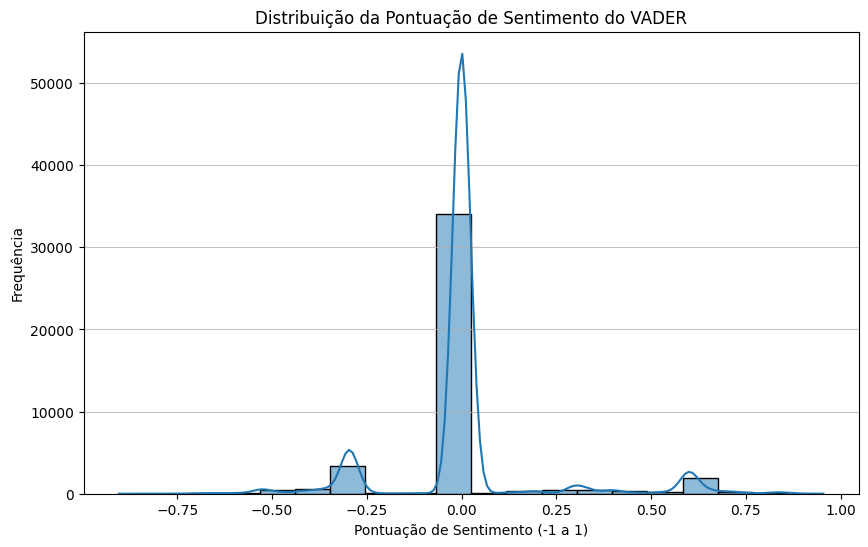

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_avaliacoes['pontuacao_sentimento_vader'], bins=20, kde=True)
plt.title('Distribuição da Pontuação de Sentimento do VADER')
plt.xlabel('Pontuação de Sentimento (-1 a 1)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Distribuição das `score_classificado_vader`

Agora, vamos ver a distribuição das classificações em estrelas (1 a 5) geradas pelo modelo VADER.

/tmp/ipykernel_6753/863454861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score_classificado_vader', data=df_avaliacoes, palette='viridis', order=sorted(df_avaliacoes['score_classificado_vader'].unique()))


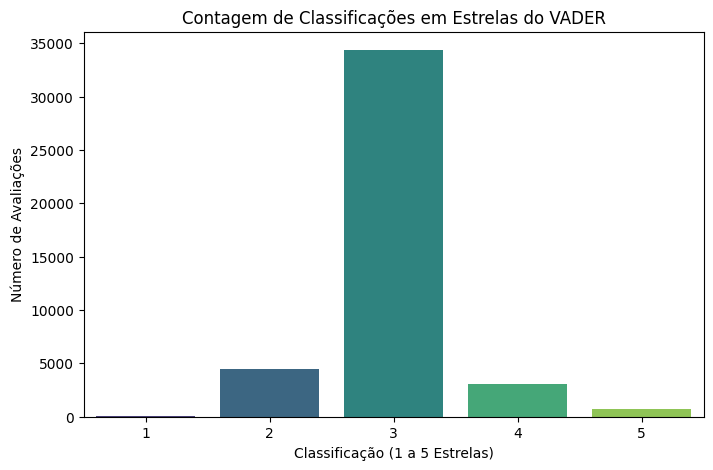

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='score_classificado_vader', data=df_avaliacoes, palette='viridis', order=sorted(df_avaliacoes['score_classificado_vader'].unique()))
plt.title('Contagem de Classificações em Estrelas do VADER')
plt.xlabel('Classificação (1 a 5 Estrelas)')
plt.ylabel('Número de Avaliações')
plt.show()

### Comparação entre `score_classificado_vader` e `review_score`

Para verificar a coerência do VADER, é fundamental comparar a classificação do modelo com a `review_score` original.

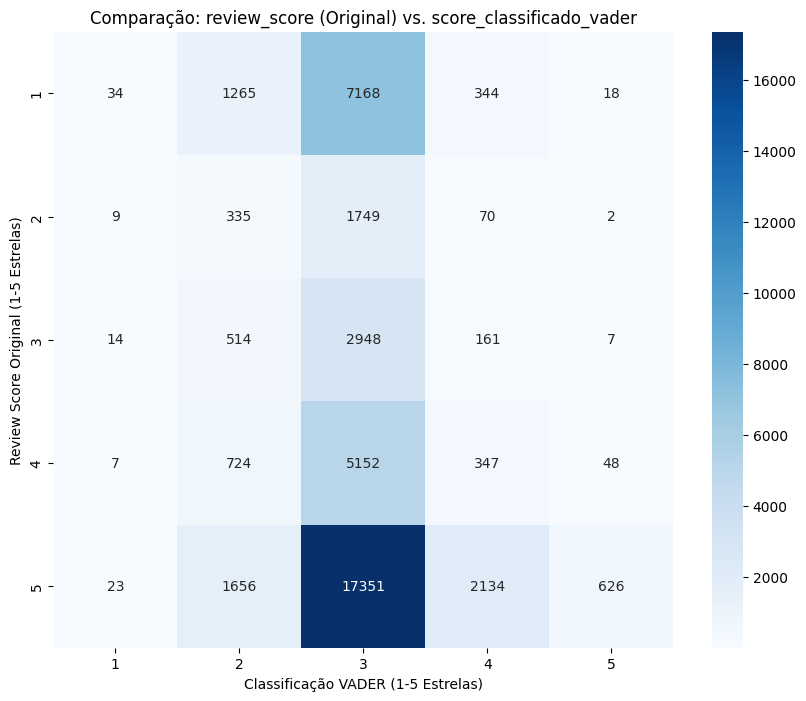


Alguns exemplos de avaliações onde a classificação do VADER difere do score original:


,review_text_combined,review_score,pontuacao_sentimento_vader,score_classificado_vader
26268,tapete muito fino - tapete muito fino...bonito...,4,0.0000,3
43268,"entregaram o pedido em duas etapas, ou seja, d...",4,-0.2960,2
8234,"produto correto, entrega feito antes do prazo ...",4,0.0000,3
61164,gostei bastante muito grande e bonita,5,0.0000,3
77803,"consultando o app, no menu "" meus pedidos"", in...",1,-0.4724,2


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.crosstab(df_avaliacoes['review_score'], df_avaliacoes['score_classificado_vader']), cmap='Blues', annot=True, fmt='d')
plt.title('Comparação: review_score (Original) vs. score_classificado_vader')
plt.xlabel('Classificação VADER (1-5 Estrelas)')
plt.ylabel('Review Score Original (1-5 Estrelas)')
plt.show()

# Exemplo de reviews onde o score do VADER difere do score original
discrepancias_vader = df_avaliacoes[df_avaliacoes['review_score'] != df_avaliacoes['score_classificado_vader']]
print("\nAlguns exemplos de avaliações onde a classificação do VADER difere do score original:")
display(discrepancias_vader[['review_text_combined', 'review_score', 'pontuacao_sentimento_vader', 'score_classificado_vader']].sample(5))

## Análise e Visualização dos Resultados do Sentimento LeIA

Agora, vamos visualizar as pontuações e classificações geradas pelo modelo LeIA para entender melhor a distribuição do sentimento e compará-las com as `review_score`s originais.

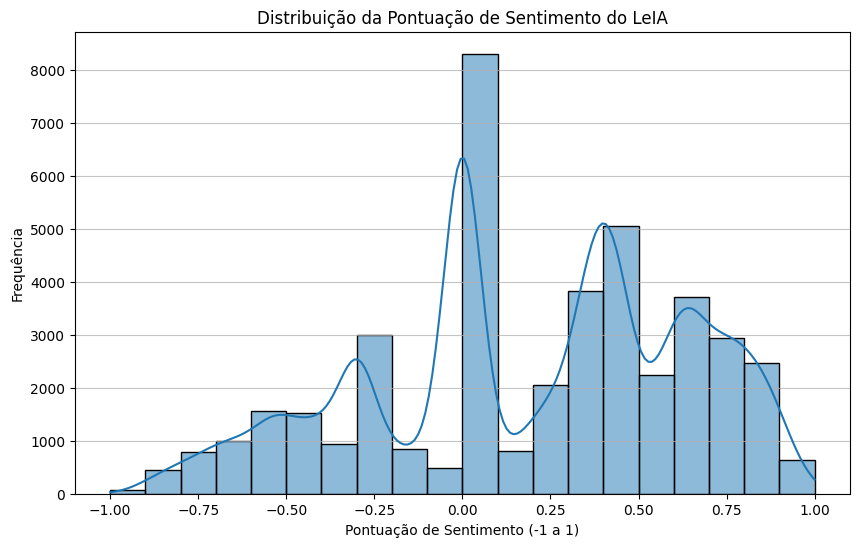

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_avaliacoes['pontuacao_sentimento_leia'], bins=20, kde=True)
plt.title('Distribuição da Pontuação de Sentimento do LeIA')
plt.xlabel('Pontuação de Sentimento (-1 a 1)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Distribuição das `score_classificado_leia`

Agora, vamos ver a distribuição das classificações em estrelas (1 a 5) geradas pelo modelo LeIA.

/tmp/ipykernel_6753/664060597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score_classificado_leia', data=df_avaliacoes, palette='viridis', order=sorted(df_avaliacoes['score_classificado_leia'].unique()))


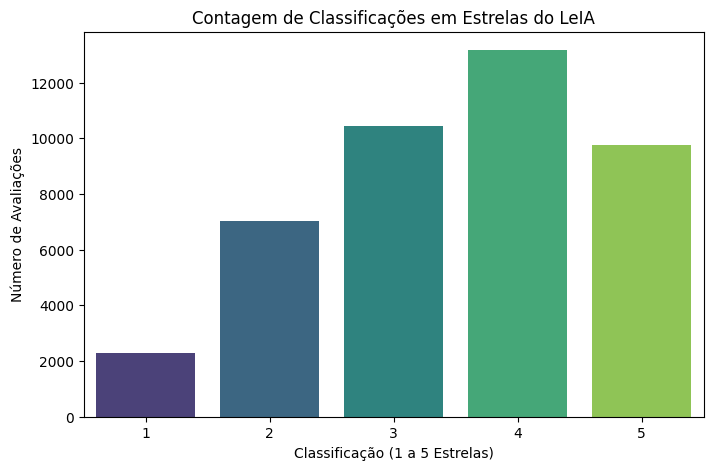

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='score_classificado_leia', data=df_avaliacoes, palette='viridis', order=sorted(df_avaliacoes['score_classificado_leia'].unique()))
plt.title('Contagem de Classificações em Estrelas do LeIA')
plt.xlabel('Classificação (1 a 5 Estrelas)')
plt.ylabel('Número de Avaliações')
plt.show()

### Comparação entre `score_classificado_leia` e `review_score`

Para verificar a coerência do LeIA, é fundamental comparar a classificação do modelo com a `review_score` original.

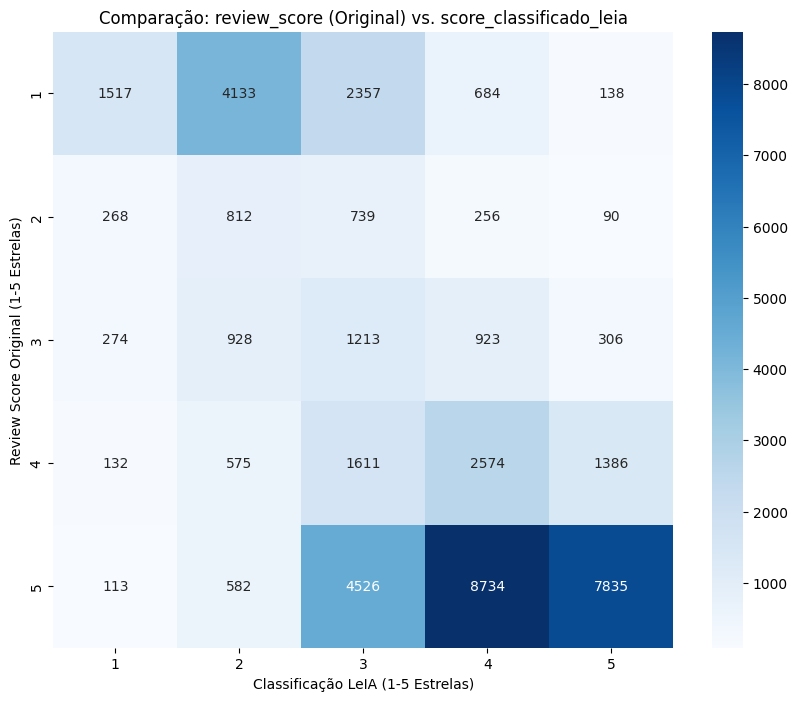


Alguns exemplos de avaliações onde a classificação do LeIA difere do score original:


,review_text_combined,review_score,pontuacao_sentimento_leia,score_classificado_leia
94465,faltou clareza quanto ao tamanho do papel. com...,3,0.8591,5
17958,apesar de estar listado como disponivel em est...,1,-0.2960,2
39989,produto otimo e lindo??,5,0.4329,4
96189,ainda nao usei o produto mas chegou completo e...,5,0.2924,4
71521,otima - recomendo!,5,0.4199,4


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.crosstab(df_avaliacoes['review_score'], df_avaliacoes['score_classificado_leia']), cmap='Blues', annot=True, fmt='d')
plt.title('Comparação: review_score (Original) vs. score_classificado_leia')
plt.xlabel('Classificação LeIA (1-5 Estrelas)')
plt.ylabel('Review Score Original (1-5 Estrelas)')
plt.show()

# Exemplo de reviews onde o score do LeIA difere do score original
discrepancias_leia = df_avaliacoes[df_avaliacoes['review_score'] != df_avaliacoes['score_classificado_leia']]
print("\nAlguns exemplos de avaliações onde a classificação do LeIA difere do score original:")
display(discrepancias_leia[['review_text_combined', 'review_score', 'pontuacao_sentimento_leia', 'score_classificado_leia']].sample(5))

## Análise e Visualização dos Resultados do Sentiment Transformers

Vamos agora visualizar as pontuações e classificações geradas pelo modelo `transformers` para entender melhor a distribuição do sentimento e compará-las com as `review_score`s originais.

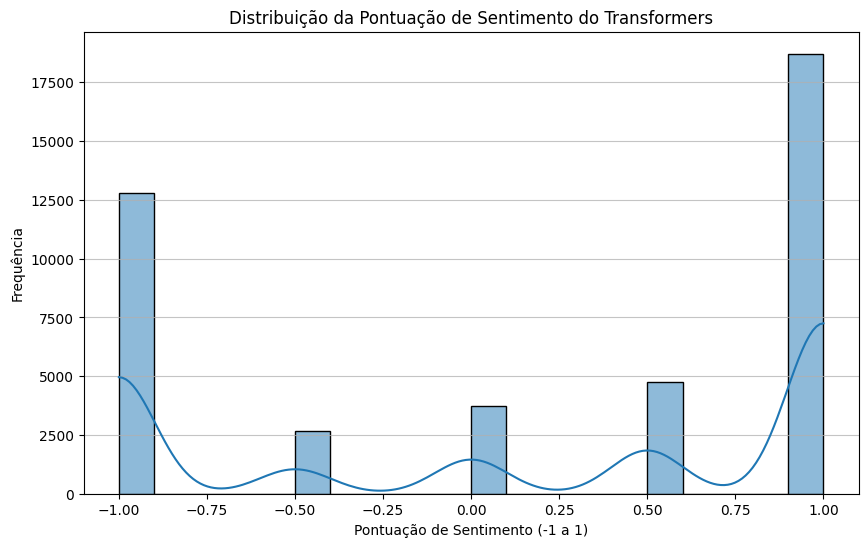

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_avaliacoes['pontuacao_sentimento_transformers'], bins=20, kde=True)
plt.title('Distribuição da Pontuação de Sentimento do Transformers')
plt.xlabel('Pontuação de Sentimento (-1 a 1)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Distribuição das `score_classificado_transformers`

Agora, vamos ver a distribuição das classificações em estrelas (1 a 5) geradas pelo modelo `transformers`.

/tmp/ipykernel_6753/808398039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score_classificado_transformers', data=df_avaliacoes, palette='viridis', order=sorted(df_avaliacoes['score_classificado_transformers'].unique()))


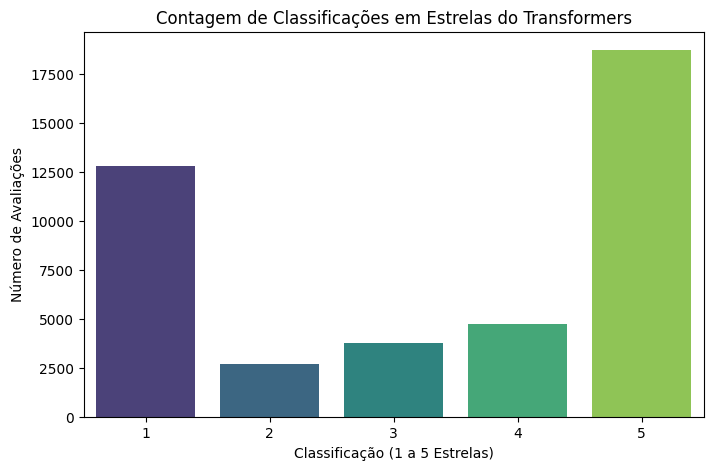

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='score_classificado_transformers', data=df_avaliacoes, palette='viridis', order=sorted(df_avaliacoes['score_classificado_transformers'].unique()))
plt.title('Contagem de Classificações em Estrelas do Transformers')
plt.xlabel('Classificação (1 a 5 Estrelas)')
plt.ylabel('Número de Avaliações')
plt.show()

### Comparação entre `score_classificado_transformers` e `review_score`

Para verificar a coerência, é fundamental comparar a classificação do modelo `transformers` com a `review_score` original (a avaliação do cliente em estrelas). Uma matriz de confusão ou um gráfico de dispersão pode nos ajudar a visualizar isso.

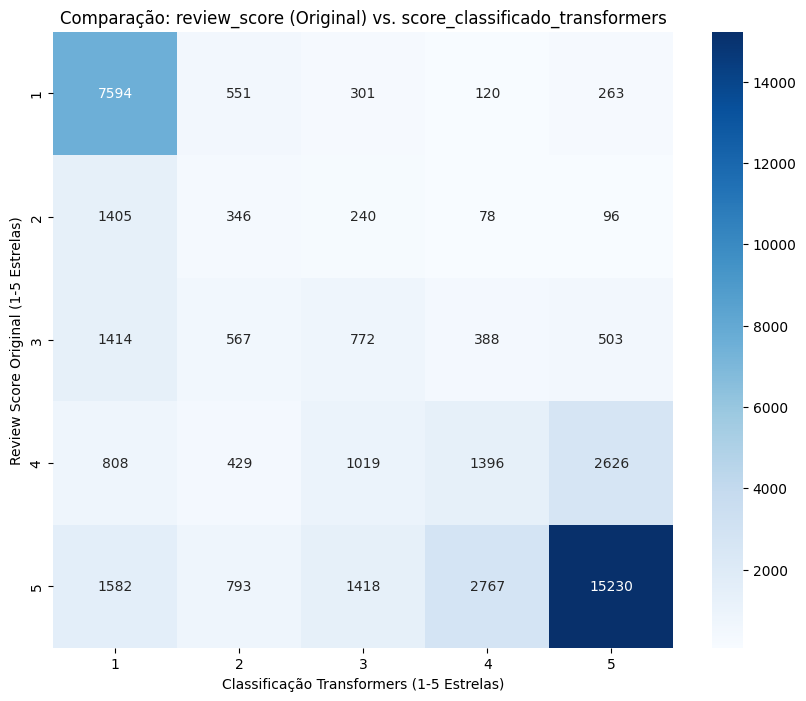


Alguns exemplos de avaliações onde a classificação do Transformers difere do score original:


,review_text_combined,review_score,pontuacao_sentimento_transformers,score_classificado_transformers
95892,chegou bem antes do prazo e happy ficou lindo ...,5,0.5,4
10059,quero o estorno - nao recebi o produto correto,3,-1.0,1
73870,s,5,0.5,4
97905,entregue no prazo,5,-1.0,1
91116,otimo,5,-0.5,2


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.crosstab(df_avaliacoes['review_score'], df_avaliacoes['score_classificado_transformers']), cmap='Blues', annot=True, fmt='d')
plt.title('Comparação: review_score (Original) vs. score_classificado_transformers')
plt.xlabel('Classificação Transformers (1-5 Estrelas)')
plt.ylabel('Review Score Original (1-5 Estrelas)')
plt.show()

# Exemplo de reviews onde o score do transformers difere do score original
discrepancias = df_avaliacoes[df_avaliacoes['review_score'] != df_avaliacoes['score_classificado_transformers']]
print("\nAlguns exemplos de avaliações onde a classificação do Transformers difere do score original:")
display(discrepancias[['review_text_combined', 'review_score', 'pontuacao_sentimento_transformers', 'score_classificado_transformers']].sample(5))

### **Análise de Discrepâncias Opostas: `review_score` vs. `score_classificado_transformers`**

Vamos identificar e analisar casos em que a classificação do usuário (`review_score`) e a classificação do modelo (`score_classificado_transformers`) são extremas e opostas (e.g., usuário deu 1 estrela, mas o modelo classificou como 5 estrelas, ou vice-versa). Isso pode indicar erros de interpretação do modelo ou talvez até sarcasmo/ironia no texto que o modelo não conseguiu capturar.

In [ ]:
# Caso 1: review_score = 1 e score_classificado_transformers = 5
contradicao_1_5 = df_avaliacoes[
    (df_avaliacoes['review_score'] == 1) &
    (df_avaliacoes['score_classificado_transformers'] == 5)
]

# Caso 2: review_score = 5 e score_classificado_transformers = 1
contradicao_5_1 = df_avaliacoes[
    (df_avaliacoes['review_score'] == 5) &
    (df_avaliacoes['score_classificado_transformers'] == 1)
]

# Combinar os dois casos de contradição
contradic_total = pd.concat([contradicao_1_5, contradicao_5_1])

# Calcular a porcentagem
total_avaliacoes = len(df_avaliacoes)
num_contradicoes = len(contradic_total)
percentual_contradicoes = (num_contradicoes / total_avaliacoes) * 100

print(f"Total de avaliações: {total_avaliacoes}")
print(f"Número de contradições (1->5 ou 5->1): {num_contradicoes}")
print(f"Percentual de contradições: {percentual_contradicoes:.2f}%")

print("\n--- Exemplos de Contradições (review_score = 1, sentiment_score = 5) ---")
display(contradicao_1_5[['review_text_combined', 'review_score', 'pontuacao_sentimento_transformers', 'score_classificado_transformers']].head())

print("\n--- Exemplos de Contradições (review_score = 5, sentiment_score = 1) ---")
display(contradicao_5_1[['review_text_combined', 'review_score', 'pontuacao_sentimento_transformers', 'score_classificado_transformers']].head())


Total de avaliações: 42706
Número de contradições (1->5 ou 5->1): 1845
Percentual de contradições: 4.32%

--- Exemplos de Contradições (review_score = 1, sentiment_score = 5) ---


,review_text_combined,review_score,pontuacao_sentimento_transformers,score_classificado_transformers
169,fiz minha compra faz 30 dias e nao recebi aind...,1,1.0,5
305,passou dos dias previstos.,1,1.0,5
664,ate o momento eu n recebir o produto,1,1.0,5
672,muito bom o produto e preco cobrado!,1,1.0,5
1037,fornecedor targaryen me mandou um massageador ...,1,1.0,5



--- Exemplos de Contradições (review_score = 5, sentiment_score = 1) ---


,review_text_combined,review_score,pontuacao_sentimento_transformers,score_classificado_transformers
24,obrigado pela atencao amim dispensada,5,-1.0,1
204,nada a declarar,5,-1.0,1
363,acho q deveriam mandar por sedex ao inves de pac,5,-1.0,1
389,"recebi o produto dentro do prazo informado, ai...",5,-1.0,1
456,chegou antes do prazo e a cabeceira e linda.,5,-1.0,1


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## **4. Comparação Direta dos Modelos de Análise de Sentimento**

Nesta seção, realizaremos uma comparação visual direta entre os três modelos de análise de sentimento (VADER, LeIA e Transformers) para entender suas semelhanças e diferenças.

### **Distribuição Comparativa das Classificações de Sentimento (1-5 Estrelas)**

Este gráfico de barras agrupa as classificações de sentimento de 1 a 5 estrelas geradas por cada modelo, permitindo visualizar como cada um distribui o sentimento geral. Isso ajuda a identificar se algum modelo tende a ser mais otimista, pessimista ou neutro em comparação com os outros.

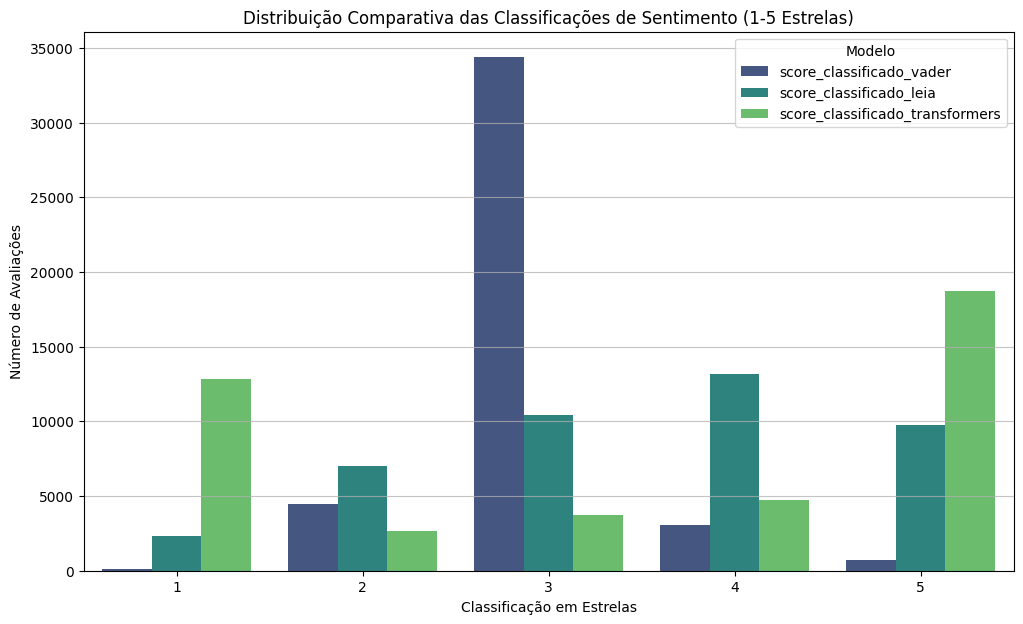

In [ ]:
df_comparativo_classificacao = df_avaliacoes[[
    'score_classificado_vader',
    'score_classificado_leia',
    'score_classificado_transformers'
]].melt(var_name='Modelo', value_name='Classificação em Estrelas')

plt.figure(figsize=(12, 7))
sns.countplot(data=df_comparativo_classificacao, x='Classificação em Estrelas', hue='Modelo', palette='viridis')
plt.title('Distribuição Comparativa das Classificações de Sentimento (1-5 Estrelas)')
plt.xlabel('Classificação em Estrelas')
plt.ylabel('Número de Avaliações')
plt.legend(title='Modelo')
plt.grid(axis='y', alpha=0.75)
plt.show()

### **Ordenação de Avaliações por Tamanho (Selection Sort)**

Esta célula aplica o algoritmo Selection Sort para ordenar as avaliações com base no comprimento do texto (do maior para o menor). Isso permite identificar rapidamente os comentários mais detalhados e extensos, que podem conter informações mais ricas.

In [ ]:
# Aplicar o selection sort na coluna 'review_text_combined' e mostrar os primeiros 10 resultados
# Fazemos uma cópia para evitar warnings do pandas sobre SettingWithCopyWarning
reviews_to_sort = df_avaliacoes['review_text_combined'].copy()

sorted_reviews = selection_sort_by_length(reviews_to_sort.tolist())

print("Comentários ordenados pelo tamanho (maior para o menor):") # Mensagem de impressão atualizada
for i, review in enumerate(sorted_reviews[:20]): # Mostrar os primeiros 20 para ter uma ideia
    print(f"({len(review)} caracteres) {review}")

Comentários ordenados pelo tamanho (maior para o menor):
(231 caracteres) nao comprem na targaryen - a empresa terceira targaryen nao e confiavel, eles vedem produtos que nao tem, voce paga, espera, nao recebe e depois tem que correr atras de reembolso.
nao recomendo de jeito nenhum esta empresa, e a su
(230 caracteres) falsificado (targaryen) - recebi um produto f-a-l-s-i-f-i-c-a-d-o. n sabe nem disfarcar. totalmente diferente do original. demora para resolver meu problema, nao consigo trocar nem pedir reembolso. nao comprem com targaryen nunca!
(229 caracteres) produto de qualidade infe - bem comprei esse quadro pela targaryen,e solicitei troca imediatamente,quadro parecido com o do anuncio no entanto apresenta impressao sem qualidade,sem foco imagem tremula,o material da tela terrivel.
(228 caracteres) vendedor sem compromisso. - comprei 3 plafons de led, 2 ralos inteligentes e 2 luminarias. um dos ralos veio quebrado, comprometendo a funcionalidade do mesmo, e as 2 luminarias simpl

### **Ordenação por Pontuação de Sentimento com Selection Sort**

Agora, vamos aplicar o `selection_sort` para ordenar as avaliações com base na `pontuacao_sentimento_transformers`. Isso nos permitirá ver os comentários mais positivos e mais negativos de acordo com a análise do modelo.

In [ ]:
# Function selection_sort_by_value_descending (Moved to consolidated functions block)

# Preparar os dados: lista de tuplas (score, review_text_combined)
data_for_sorting = list(zip(df_avaliacoes['pontuacao_sentimento_transformers'], df_avaliacoes['review_text_combined']))

# Aplicar o selection sort
sorted_sentiment_reviews = selection_sort_by_value_descending(data_for_sorting)

print("Comentários ordenados pela pontuação de sentimento (mais positiva para mais negativa - Transformers):")
for score, review in sorted_sentiment_reviews[:10]: # Mostrar os 10 mais positivos
    print(f"({score:.2f}) {review}")

print("\n" + "="*70 + "\n")

print("Comentários ordenados pela pontuação de sentimento (mais negativa para mais positiva - Transformers):")
for score, review in sorted_sentiment_reviews[-10:]: # Mostrar os 10 mais negativos
    print(f"({score:.2f}) {review}")

Comentários ordenados pela pontuação de sentimento (mais positiva para mais negativa - Transformers):
(1.00) parabens lojas lannister adorei comprar pela internet seguro e pratico parabens a todos feliz pascoa
(1.00) super recomendo - vendedor confiavel, produto ok e entrega antes do prazo.
(1.00) otimo - loja nota 10
(1.00) a compra foi realizada facilmente.
a entrega foi efetuada muito antes do prazo dado.
o produto ja comecou a ser usado e ate o presente,
sem problemas.
(1.00) relogio muito bonito e barato.
(1.00) muito bom. - recebi exatamente o que esperava. as demais encomendas de outros vendedores atrasaram, mas esta chegou no prazo.
(1.00) bom - recomendo ,
(1.00) muito boa 
(1.00) maravilhoso! - to completamente apaixonada, loja super responsavel e confiavel!
(1.00) entrega perfeita - muito bom. muito cheiroso.


Comentários ordenados pela pontuação de sentimento (mais negativa para mais positiva - Transformers):
(-1.00) nao foi entregue o pedido - bom dia 
das 6 unidades comp

### **Ordenação por Pontuação de Sentimento com Selection Sort (VADER)**

Agora, vamos aplicar o `selection_sort` para ordenar as avaliações com base na `pontuacao_sentimento_vader`. Isso nos permitirá ver os comentários mais positivos e mais negativos de acordo com a análise do modelo VADER.

In [ ]:
# Preparar os dados: lista de tuplas (score, review_text_combined)
data_for_sorting_vader = list(zip(df_avaliacoes['pontuacao_sentimento_vader'], df_avaliacoes['review_text_combined']))

# Aplicar o selection sort
sorted_sentiment_reviews_vader = selection_sort_by_value_descending(data_for_sorting_vader)

print("Comentários ordenados pela pontuação de sentimento (mais positiva para mais negativa - VADER):")
for score, review in sorted_sentiment_reviews_vader[:10]: # Mostrar os 10 mais positivos
    print(f"({score:.2f}) {review}")

print("\n" + "="*70 + "\n")

print("Comentários ordenados pela pontuação de sentimento (mais negativa para mais positiva - VADER):")
for score, review in sorted_sentiment_reviews_vader[-10:]: # Mostrar os 10 mais negativos
    print(f"({score:.2f}) {review}")

Comentários ordenados pela pontuação de sentimento (mais positiva para mais negativa - VADER):
(0.95) super top  - produtos lindos super da hora, chegaram em menos de 5 dias da data da compra e a previsao eram quase 30 dias , qualidade super boa , super indico 
(0.93) super satisfeita - otimo produto!! chegou super rapido!!! otima qualidade!!! super recomendo! e lindaaaaaaa e bem grande!! 
(0.93) vendedor super atencioso! - loja super completa! o vendedor e atencioso e super agil nos prazo! vale a pena
(0.92) super recomendo - entrega super rapida e o produto e muito bom! estou super satisfeita!
(0.92) super recomendo!! - super recomendo, chegou super rapido. 
(0.91) super recomendo  - amei o produto, chegou antes da data prevista para entrega, super amei, super recomendo 
(0.91) otimo e super rapido - produto otimo e entrega super rapida , super recomendo 
(0.91) o produto e excelente, muito resistente e atendeu as minhas expectativas. sou cliente ha anos do baratheon porque e super c

### **Ordenação por Pontuação de Sentimento com Selection Sort (LeIA)**

Agora, vamos aplicar o `selection_sort` para ordenar as avaliações com base na `pontuacao_sentimento_leia`. Isso nos permitirá ver os comentários mais positivos e mais negativos de acordo com a análise do modelo LeIA.

In [ ]:
# Preparar os dados: lista de tuplas (score, review_text_combined)
data_for_sorting_leia = list(zip(df_avaliacoes['pontuacao_sentimento_leia'], df_avaliacoes['review_text_combined']))

# Aplicar o selection sort
sorted_sentiment_reviews_leia = selection_sort_by_value_descending(data_for_sorting_leia)

print("Comentários ordenados pela pontuação de sentimento (mais positiva para mais negativa - LeIA):")
for score, review in sorted_sentiment_reviews_leia[:10]: # Mostrar os 10 mais positivos
    print(f"({score:.2f}) {review}")

print("\n" + "="*70 + "\n")

print("Comentários ordenados pela pontuação de sentimento (mais negativa para mais positiva - LeIA):")
for score, review in sorted_sentiment_reviews_leia[-10:]: # Mostrar os 10 mais negativos
    print(f"({score:.2f}) {review}")

Comentários ordenados pela pontuação de sentimento (mais positiva para mais negativa - LeIA):
(1.00) 










(1.00) 


(1.00) 

(1.00) 
(1.00) 
(1.00) 

(1.00) 
(1.00) 
(1.00) 
(1.00) 


Comentários ordenados pela pontuação de sentimento (mais negativa para mais positiva - LeIA):
(-0.94) horrivel  - muito ruim!! embalaram ele dobrado e por isso quando enche ele e dificil desamassar!! pessimo... estou insatisfeito com o produto... desapontado. 
(-0.94) seu processo em minha opiniao esta errado por nao haver quem atenda a chamada para tirar duvidas, essa compra foi altamente estressante, pois so depois de um tempo consegui resolver meu problema. 
(-0.94) este produto foi um dos pior que ja adquiri,pois nao prende ,nao fica preso a cabeca.no primeiro movimento que vc faz ele solta da cabeca.este produto nao tem qualidade para ser vendido pelo shptime.
(-0.95) nao comprem esse produto, muito mal acabado, veio acabamento com furos no pe da cadeira, acabamento das costas com furos errados

## **5. Conclusão e Observações Finais**

Esta seção resume os principais insights obtidos da análise de sentimento utilizando os modelos VADER, LeIA e Transformers, destacando suas características e como se comportaram em relação às `review_score`s originais.

### **VADER:**

*   **Força:** Extremamente rápido e eficiente para grandes volumes de dados. Tende a ser mais conservador, com uma concentração maior de pontuações neutras ou próximas ao zero.
*   **Limitação:** Por ser baseado em léxicos, pode ter dificuldade em capturar nuances e gírias específicas do português ou sarcasmo, resultando em menor alinhamento com `review_score`s extremas (1 ou 5) em alguns casos.

### **LeIA:**

*   **Força:** Desenvolvido especificamente para o português, o que lhe confere uma vantagem na compreensão de idiomatismos e estruturas gramaticais locais. Geralmente apresenta um bom equilíbrio entre velocidade e acurácia para o idioma.
*   **Limitação:** Assim como o VADER, por ser léxico-baseado, pode não capturar completamente o contexto de frases mais complexas ou ambíguas.

### **Transformers (nlptown/bert-base-multilingual-uncased-sentiment):**

*   **Força:** Modelo de aprendizado de máquina pré-treinado, o que lhe permite um entendimento contextual muito mais profundo do texto. Capaz de capturar sentimentos com maior precisão, mesmo em frases complexas, e lida bem com múltiplos idiomas.
*   **Limitação:** É o mais lento dos três devido à sua complexidade. O mapeamento de 'estrelas' para uma pontuação contínua pode introduzir alguma granularidade na comparação direta com scores contínuos de VADER e LeIA.

### **Observações Gerais:**

*   **Concordância:** Observamos nos mapas de calor que todos os modelos demonstraram uma concordância razoável com as `review_score`s originais, especialmente nas pontuações extremas (1 e 5). As maiores divergências geralmente ocorrem nas classificações intermediárias.
*   **Correlação:** A matriz de correlação das pontuações contínuas mostra o nível de alinhamento entre os modelos. É comum que VADER e LeIA (ambos léxico-baseados) apresentem uma correlação mais próxima entre si do que com o Transformers, que utiliza uma abordagem contextual.
*   **Escolha do Modelo:** A escolha do modelo ideal depende do equilíbrio entre **velocidade** e **precisão** exigido pelo caso de uso. Para análises rápidas e gerais, VADER ou LeIA podem ser suficientes. Para uma compreensão mais profunda e precisa do sentimento, especialmente em textos com maior complexidade, Transformers é a escolha superior, embora com custo computacional maior.

### **Próximos Passos (Potenciais Aprimoramentos):**

1.  **Avaliação Quantitativa Rigorosa:** Se disponível, usar um conjunto de dados de avaliações com sentimentos rotulados manualmente (ground truth) para calcular métricas como acurácia, precisão, recall e F1-score para cada modelo. Isso permitiria uma comparação de desempenho mais objetiva.
2.  **Análise de Erros:** Investigar em profundidade os casos de maior discrepância entre os modelos e a `review_score` original para entender o porquê das diferenças (e.g., sarcasmo, duplos sentidos, especificidades do domínio).
3.  **Análise Temática de Sentimento:** Utilizar os scores de sentimento em conjunto com outras variáveis (e.g., categoria do produto, vendedor) para identificar padrões e insights de negócio, como produtos que geram mais insatisfação ou vendedores com melhor reputação de atendimento.